In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [84]:
def d_k(K,s,r,sigma,T,t):
    return (np.log(K/s)-(r-0.5*sigma**2)*(T-t))/(sigma*np.sqrt(T-t))


def Delta(t,s):
    K1 = 90; K2= 110; r=0.05; sigma = 0.2; T = 1
    return np.exp(-r*(T-t))*(-1/(s*sigma*np.sqrt(T-t)))*(stats.norm.pdf(d_k(K2,s,r,sigma,T,t))-stats.norm.pdf(d_k(K1,s,r,sigma,T,t)))


def mult(K,s,r,sigma,T,t):
    return 0.5*np.sqrt(T-t)-(np.log(K/s)-r*(T-t))/(sigma**2*np.sqrt(T-t))

def Vega(t,s):
    K1 = 90; K2= 110; r=0.05; sigma = 0.2; T = 1
    return np.exp(-r*(T-t))*(mult(K2,s,r,sigma,T,t)*stats.norm.pdf(d_k(K2,s,r,sigma,T,t))-mult(K1,s,r,sigma,T,t)*stats.norm.pdf(d_k(K1,s,r,sigma,T,t)))


In [101]:
N = 200
eps = 1e-2
S_v = np.linspace(50,150,num=3*N)
t_v = np.linspace(0+eps,1-eps,num=N)
T_, S_ = np.meshgrid(t_v, S_v)
D = Delta(T_, S_)                 
V = Vega(T_, S_)

In [102]:
print(T_.shape, S_.shape)
print(D.shape)

(600, 200) (600, 200)
(600, 200)


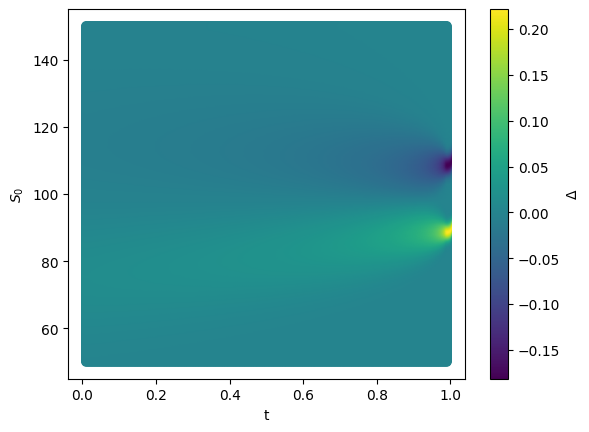

In [103]:
sc = plt.scatter(
    T_,
    S_,              
    c=D,      
    cmap="viridis"
)
cbar = plt.colorbar(sc)
plt.xlabel("t"); plt.ylabel(f"$S_0$"), cbar.set_label("$\Delta$")
plt.show()

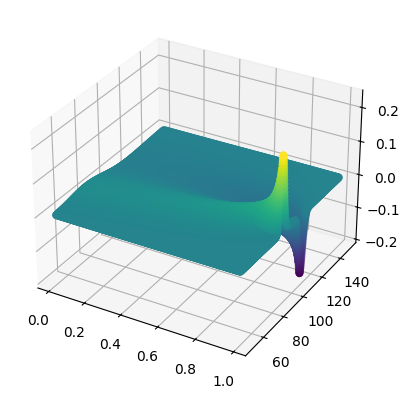

In [104]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(    T_,
    S_,              
    D,c=D)
plt.show()

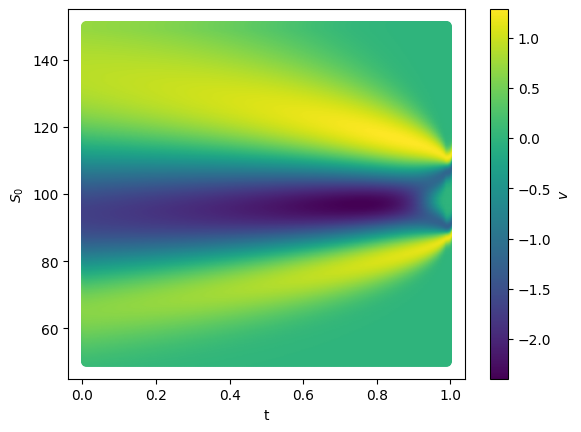

In [105]:
sc2 = plt.scatter(
    T_,
    S_,              
    c=V,      
    cmap="viridis"
)
cbar = plt.colorbar(sc2)
plt.xlabel("t"); plt.ylabel(f"$S_0$"), cbar.set_label("$v$")
plt.show()

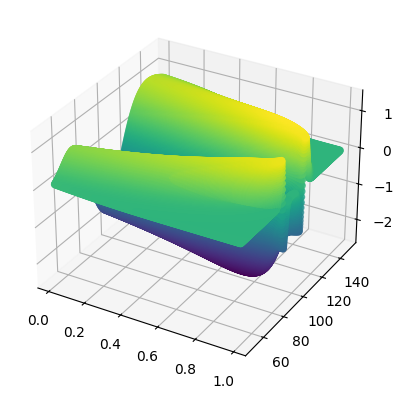

In [106]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(    T_,
    S_,              
    V,c=V)
plt.show()